# ConvNeXt-Tiny

- Предобученная модель (timm), 4 класса застройки
- Этап 1: обучение головы, подбор LR
- Этап 2: постепенная разморозка слоёв, LR ниже
- Ранняя остановка, графики, матрица ошибок, примеры

Split: `data/processed/split.csv` (как в `02_baseline.ipynb`).

In [1]:
import copy
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader

sys.path.insert(0, str(Path('..').resolve() / 'src'))

from dataset import BuildingDataset, CLASSES, get_train_transforms, get_transforms, load_split
from model_convnext import build_convnext_tiny, unfreeze_all, unfreeze_stages, count_trainable_params
from utils import (
    CONVNEXT_TINY as CFG,
    IMAGE_SIZE,
    MODELS_DIR,
    NUM_WORKERS,
    PLOT_DPI,
    RANDOM_SEED,
    REPORTS_DIR,
    SPLIT_CSV,
    ensure_dirs,
    set_random_seed,
)

BATCH_SIZE = CFG.batch_size
MAX_EPOCHS = CFG.max_epochs
LOSS_EPS = CFG.loss_eps
PATIENCE = CFG.patience
MIN_EPOCHS = CFG.min_epochs
WEIGHT_DECAY = CFG.weight_decay

LR_CANDIDATES = CFG.lr_candidates
STAGE1_MAX_EPOCHS = CFG.stage1_max_epochs
STAGE1_MIN_EPOCHS = CFG.stage1_min_epochs
STAGE1_PATIENCE = CFG.stage1_patience
STAGE2_STEPS = CFG.stage2_steps
STAGE2_MIN_EPOCHS_FLOOR = CFG.stage2_min_epochs_floor

ensure_dirs()
set_random_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)
if torch.cuda.is_available():
    print('ГПУ:', torch.cuda.get_device_name(0))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = CFG.figure_size

Устройство: cuda
ГПУ: NVIDIA GeForce RTX 4060 Laptop GPU


## Данные

`split.csv` — те же train / val / test, что в baseline.

In [2]:
if not SPLIT_CSV.exists():
    raise FileNotFoundError(
        f'{SPLIT_CSV} не найден. Split создаётся в 02_baseline.ipynb.'
    )

split_df = load_split(SPLIT_CSV)
print('Размеры выборок:')
_split_ru = {'train': 'обучение', 'val': 'валидация', 'test': 'тест'}
_split_counts = split_df['split'].value_counts().reindex(['train', 'val', 'test'])
_split_counts.index = [_split_ru[k] for k in _split_counts.index]
print(_split_counts)
print()
print('Источники данных:')
print(split_df['source'].value_counts())

Размеры выборок:
обучение     2197
валидация     471
тест          471
Name: count, dtype: int64

Источники данных:
source
NWPU-RESISC45    1696
AID              1443
Name: count, dtype: int64


## DataLoader

In [3]:
eval_transform = get_transforms(image_size=IMAGE_SIZE)
train_transform = get_train_transforms(image_size=IMAGE_SIZE, augment=True)

train_ds = BuildingDataset(split_df, split='train', classes=CLASSES, transform=train_transform)
val_ds = BuildingDataset(split_df, split='val', classes=CLASSES, transform=eval_transform)
test_ds = BuildingDataset(split_df, split='test', classes=CLASSES, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Обучение: {len(train_ds)} | Валидация: {len(val_ds)} | Тест: {len(test_ds)}')

Обучение: 2197 | Валидация: 471 | Тест: 471


## Одна эпоха

In [4]:
def run_epoch(loader, model, criterion, optimizer=None):
    """Одна эпоха: обучение или оценка."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    return avg_loss, accuracy, macro_f1


@torch.no_grad()
def collect_predictions(loader, model):
    """Предсказания модели на выборке."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.tolist())
        all_probs.extend(probs.cpu().tolist())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


def _loss_plateau(val_losses, eps=LOSS_EPS, patience=PATIENCE):
    """Loss на val почти не меняется несколько эпох подряд."""
    if len(val_losses) < patience + 1:
        return False
    recent = val_losses[-patience:]
    return all(abs(recent[i] - recent[i - 1]) < eps for i in range(1, len(recent)))


def train_loop(model, train_loader, val_loader, lr, max_epochs=MAX_EPOCHS, min_epochs=MIN_EPOCHS,
               loss_eps=LOSS_EPS, patience=PATIENCE, weight_decay=WEIGHT_DECAY, label='', verbose=True):
    """Цикл обучения с ранней остановкой."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'val_f1', 'lr']}
    best_val_f1, best_epoch = -1.0, 0
    best_state = copy.deepcopy(model.state_dict())
    prefix = f'[{label}] ' if label else ''

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        train_loss, train_acc, _ = run_epoch(train_loader, model, criterion, optimizer)
        val_loss, val_acc, val_f1 = run_epoch(val_loader, model, criterion, optimizer=None)
        scheduler.step(val_loss)
        lr_now = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lr'].append(lr_now)

        is_best = val_f1 > best_val_f1
        if is_best:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        if verbose:
            marker = ' <- лучшая' if is_best else ''
            print(
                f'{prefix}Эпоха {epoch:3d}/{max_epochs} | '
                f'потери_обуч={train_loss:.4f} точн_обуч={train_acc:.4f} | '
                f'потери_пров={val_loss:.4f} точн_пров={val_acc:.4f} macro F1={val_f1:.4f} | '
                f'{time.time() - t0:.1f}s{marker}'
            )

        if epoch >= min_epochs and _loss_plateau(history['val_loss'], loss_eps, patience):
            if verbose:
                print(f'{prefix}Ранняя остановка')
            break

    return {
        'history': history,
        'best_f1': best_val_f1,
        'best_acc': history['val_acc'][best_epoch - 1],
        'best_epoch': best_epoch,
        'best_state': best_state,
        'epochs_run': len(history['train_loss']),
    }


def print_classification_report_ru(y_true, y_pred, target_names):
    """Отчёт по классам."""
    report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True, zero_division=0)
    print(f"{'класс':<22} {'прециз.':>8} {'полнота':>8} {'F1':>8} {'объектов':>8}")
    for name in target_names:
        r = report[name]
        print(f"{name:<22} {r['precision']:8.2f} {r['recall']:8.2f} {r['f1-score']:8.2f} {int(r['support']):8d}")
    n = int(report['macro avg']['support'])
    print(f"{'точность':<22} {report['accuracy']:8.2f} {'':>8} {'':>8} {n:8d}")
    m = report['macro avg']
    print(f"{'среднее macro':<22} {m['precision']:8.2f} {m['recall']:8.2f} {m['f1-score']:8.2f} {n:8d}")
    w = report['weighted avg']
    print(f"{'среднее взвеш.':<22} {w['precision']:8.2f} {w['recall']:8.2f} {w['f1-score']:8.2f} {n:8d}")


## Этап 1: подбор LR

Кандидаты: `1e-3`, `1e-4`, `1e-5`. Заморожена основа, обучается только голова.

In [5]:
criterion = nn.CrossEntropyLoss()

lr_search_results = {}
stage1_best_state = None
stage1_best_f1 = -1.0
best_lr = None

for lr in LR_CANDIDATES:
    torch.manual_seed(RANDOM_SEED)
    model = build_convnext_tiny(num_classes=len(CLASSES), freeze_backbone=True).to(device)
    print(f'\n--- LR={lr:.0e} | обучаемых параметров: {count_trainable_params(model):,} ---')

    result = train_loop(
        model, train_loader, val_loader, lr,
        max_epochs=STAGE1_MAX_EPOCHS,
        min_epochs=STAGE1_MIN_EPOCHS,
        patience=STAGE1_PATIENCE,
        label=f'этап1_{lr:.0e}',
    )

    lr_search_results[lr] = {
        'best_val_f1': result['best_f1'],
        'best_val_acc': result['best_acc'],
        'epochs_run': result['epochs_run'],
        'history': result['history'],
    }

    if result['best_f1'] > stage1_best_f1:
        stage1_best_f1 = result['best_f1']
        stage1_best_state = result['best_state']
        best_lr = lr

print(f'\nЛучший LR для этапа 1: {best_lr:.0e} (macro F1={stage1_best_f1:.4f})')


--- LR=1e-03 | обучаемых параметров: 4,612 ---
[этап1_1e-03] Эпоха   1/15 | потери_обуч=0.4625 точн_обуч=0.8402 | потери_пров=0.2376 точн_пров=0.9321 macro F1=0.9335 | 24.9s <- лучшая
[этап1_1e-03] Эпоха   2/15 | потери_обуч=0.1718 точн_обуч=0.9531 | потери_пров=0.1725 точн_пров=0.9490 macro F1=0.9498 | 21.7s <- лучшая
[этап1_1e-03] Эпоха   3/15 | потери_обуч=0.1234 точн_обуч=0.9709 | потери_пров=0.1479 точн_пров=0.9618 macro F1=0.9625 | 21.5s <- лучшая
[этап1_1e-03] Эпоха   4/15 | потери_обуч=0.0994 точн_обуч=0.9750 | потери_пров=0.1298 точн_пров=0.9618 macro F1=0.9624 | 21.1s
[этап1_1e-03] Эпоха   5/15 | потери_обуч=0.0843 точн_обуч=0.9777 | потери_пров=0.1061 точн_пров=0.9703 macro F1=0.9708 | 25.4s <- лучшая
[этап1_1e-03] Эпоха   6/15 | потери_обуч=0.0705 точн_обуч=0.9822 | потери_пров=0.0993 точн_пров=0.9682 macro F1=0.9686 | 28.3s
[этап1_1e-03] Эпоха   7/15 | потери_обуч=0.0657 точн_обуч=0.9836 | потери_пров=0.0926 точн_пров=0.9724 macro F1=0.9729 | 28.3s <- лучшая
[этап1_1e-03]


--- LR=1e-04 | обучаемых параметров: 4,612 ---
[этап1_1e-04] Эпоха   1/15 | потери_обуч=1.1299 точн_обуч=0.5353 | потери_пров=0.8958 точн_пров=0.7282 macro F1=0.7344 | 29.0s <- лучшая
[этап1_1e-04] Эпоха   2/15 | потери_обуч=0.7184 точн_обуч=0.8134 | потери_пров=0.6320 точн_пров=0.8365 macro F1=0.8393 | 29.0s <- лучшая
[этап1_1e-04] Эпоха   3/15 | потери_обуч=0.5316 точн_обуч=0.8812 | потери_пров=0.5007 точн_пров=0.8577 macro F1=0.8600 | 29.1s <- лучшая
[этап1_1e-04] Эпоха   4/15 | потери_обуч=0.4237 точн_обуч=0.9053 | потери_пров=0.4191 точн_пров=0.8981 macro F1=0.8998 | 29.0s <- лучшая
[этап1_1e-04] Эпоха   5/15 | потери_обуч=0.3625 точн_обуч=0.9172 | потери_пров=0.3693 точн_пров=0.9108 macro F1=0.9124 | 29.0s <- лучшая
[этап1_1e-04] Эпоха   6/15 | потери_обуч=0.3156 точн_обуч=0.9281 | потери_пров=0.3308 точн_пров=0.9193 macro F1=0.9208 | 33.0s <- лучшая
[этап1_1e-04] Эпоха   7/15 | потери_обуч=0.2861 точн_обуч=0.9349 | потери_пров=0.3000 точн_пров=0.9299 macro F1=0.9311 | 46.0s <- 

In [6]:
lr_summary = pd.DataFrame([
    {
        'LR': lr,
        'macro F1': res['best_val_f1'],
        'точность': res['best_val_acc'],
        'эпох': res['epochs_run'],
    }
    for lr, res in lr_search_results.items()
])
print(lr_summary)

        LR  macro F1  точность  эпох
0  0.00100  0.983354  0.983015    15
1  0.00010  0.954145  0.953291    15
2  0.00001  0.802970  0.800425    15


## Этап 2: дообучение

Старт с лучших весов этапа 1. Три шага — размораживается больше слоёв, LR ниже:

1. 2 последних блока — `best_lr / 10`
2. все 4 блока — `best_lr / 20`
3. вся сеть — `best_lr / 50`

На каждом шаге — ранняя остановка. Лучшая модель — по macro F1 на val.

In [7]:
def run_progressive_finetune(train_loader):
    """Три подэтапа с разморозкой блоков."""
    substage_results = []
    best_substage = None
    combined_history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'val_f1', 'lr']}
    best_f1, best_acc, best_state = -1.0, 0.0, None
    remaining_epochs = MAX_EPOCHS
    carry_state = stage1_best_state
    carry_lr = None  # LR, на котором остановился предыдущий подэтап

    for step_idx, (n_stages, lr_divisor) in enumerate(STAGE2_STEPS):
        if remaining_epochs <= 0:
            break

        torch.manual_seed(RANDOM_SEED)
        model = build_convnext_tiny(num_classes=len(CLASSES), freeze_backbone=True).to(device)
        model.load_state_dict(carry_state)

        if step_idx == len(STAGE2_STEPS) - 1:
            unfreeze_all(model)
            stage_label = 'вся сеть'
        else:
            unfreeze_stages(model, n_stages)
            stage_label = f'последние {n_stages} стадии'

        target_lr = best_lr / lr_divisor
        # Не даём LR подскочить вверх по сравнению с тем, до чего он уже успел
        # снизиться в предыдущем подэтапе (ReduceLROnPlateau мог опустить его сильно ниже
        # номинального target_lr) — иначе разморозка новых слоёв на резко возросшем LR
        # даёт всплеск ошибки на валидации.
        fine_tune_lr = min(carry_lr, target_lr) if carry_lr is not None else target_lr
        print(
            f'\n--- Подэтап {step_idx + 1}/{len(STAGE2_STEPS)}: {stage_label} | '
            f'LR={fine_tune_lr:.1e} | обучаемых параметров: {count_trainable_params(model):,} ---'
        )

        result = train_loop(
            model, train_loader, val_loader, fine_tune_lr,
            max_epochs=remaining_epochs,
            min_epochs=max(STAGE2_MIN_EPOCHS_FLOOR, MIN_EPOCHS // 3),
            label=f'этап2_{step_idx + 1}',
        )

        for key in combined_history:
            combined_history[key].extend(result['history'][key])

        substage_results.append({
            'substage': step_idx + 1,
            'epochs_run': result['epochs_run'],
            'best_f1': result['best_f1'],
            'best_epoch': result['best_epoch'],
        })

        remaining_epochs = MAX_EPOCHS - len(combined_history['train_loss'])
        carry_state = result['best_state']
        carry_lr = result['history']['lr'][-1]

        if result['best_f1'] > best_f1:
            best_f1 = result['best_f1']
            best_acc = result['best_acc']
            best_state = result['best_state']
            best_substage = step_idx + 1

    return {
        'history': combined_history,
        'best_f1': best_f1,
        'best_acc': best_acc,
        'best_state': best_state,
        'epochs_run': len(combined_history['train_loss']),
        'substage_results': substage_results,
        'best_substage': best_substage,
    }


stage2_result = run_progressive_finetune(train_loader)
print(f'\nЭтап 2 завершён за {stage2_result["epochs_run"]} эпох')
print(f'Лучший macro F1 на валидации: {stage2_result["best_f1"]:.4f}')


--- Подэтап 1/3: последние 2 стадии | LR=1.0e-04 | обучаемых параметров: 26,588,164 ---
[этап2_1] Эпоха   1/100 | потери_обуч=0.1021 точн_обуч=0.9631 | потери_пров=0.0665 точн_пров=0.9724 macro F1=0.9730 | 36.3s <- лучшая
[этап2_1] Эпоха   2/100 | потери_обуч=0.0169 точн_обуч=0.9945 | потери_пров=0.0659 точн_пров=0.9745 macro F1=0.9752 | 35.0s <- лучшая
[этап2_1] Эпоха   3/100 | потери_обуч=0.0022 точн_обуч=1.0000 | потери_пров=0.0385 точн_пров=0.9915 macro F1=0.9917 | 34.8s <- лучшая
[этап2_1] Эпоха   4/100 | потери_обуч=0.0009 точн_обуч=1.0000 | потери_пров=0.0403 точн_пров=0.9936 macro F1=0.9938 | 35.1s <- лучшая
[этап2_1] Эпоха   5/100 | потери_обуч=0.0007 точн_обуч=1.0000 | потери_пров=0.0516 точн_пров=0.9894 macro F1=0.9897 | 34.8s
[этап2_1] Эпоха   6/100 | потери_обуч=0.0005 точн_обуч=1.0000 | потери_пров=0.0524 точн_пров=0.9894 macro F1=0.9897 | 35.1s
[этап2_1] Эпоха   7/100 | потери_обуч=0.0004 точн_обуч=1.0000 | потери_пров=0.0511 точн_пров=0.9894 macro F1=0.9897 | 35.1s
[эт

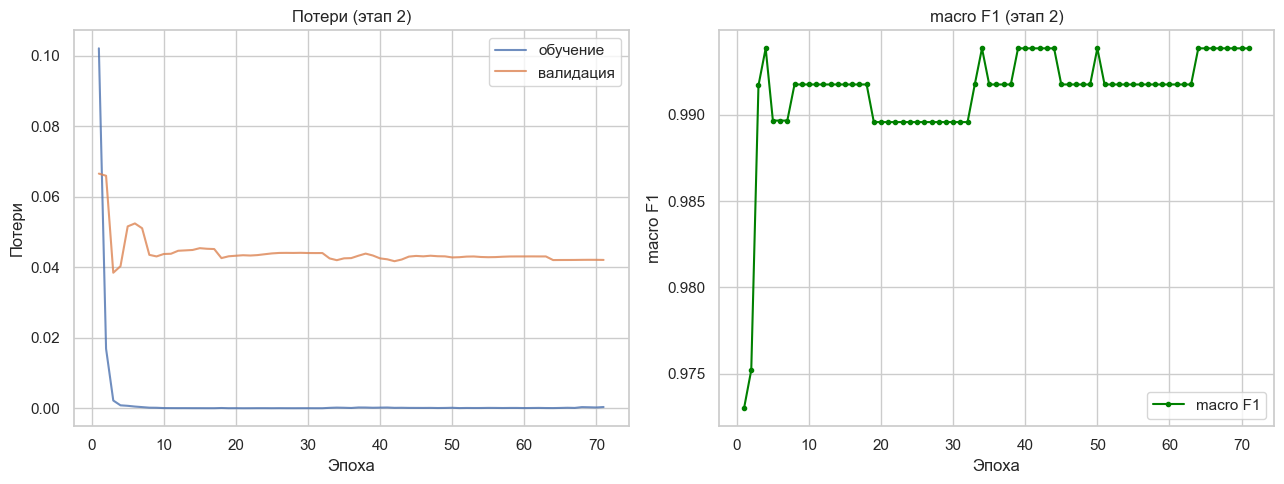

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(stage2_result['history']['val_loss']) + 1)

axes[0].plot(epochs_range, stage2_result['history']['train_loss'], label='обучение', alpha=0.8)
axes[0].plot(epochs_range, stage2_result['history']['val_loss'], label='валидация', alpha=0.8)
axes[0].set_title('Потери (этап 2)')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Потери')
axes[0].legend()

axes[1].plot(epochs_range, stage2_result['history']['val_f1'], label='macro F1', color='green', marker='o', markersize=3)
axes[1].set_title('macro F1 (этап 2)')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('macro F1')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / CFG.training_curves_plot, dpi=PLOT_DPI)
plt.show()

## Сохранение модели

Лучшие веса → `models/convnext_best.pth`.

In [9]:
best_model_path = MODELS_DIR / CFG.model_filename
torch.save(stage2_result['best_state'], best_model_path)

print('ConvNeXt-Tiny, без аугментаций')
print(f'Точность на валидации: {stage2_result["best_acc"]:.4f}')
print(f'macro F1 на валидации: {stage2_result["best_f1"]:.4f}')
print(f'Модель сохранена: {best_model_path}')

ConvNeXt-Tiny, без аугментаций
Точность на валидации: 0.9936
macro F1 на валидации: 0.9938
Модель сохранена: D:\building-type-classification\models\convnext_best.pth


## Метрики и матрица ошибок

In [10]:
final_model = build_convnext_tiny(num_classes=len(CLASSES), freeze_backbone=False).to(device)
final_model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
final_model.eval()

val_preds, val_labels, val_probs = collect_predictions(val_loader, final_model)

convnext_val_accuracy = float(np.mean(val_preds == val_labels))
convnext_val_macro_f1 = float(f1_score(val_labels, val_preds, average='macro', zero_division=0))

print(f'Точность на валидации: {convnext_val_accuracy:.4f}')
print(f'macro F1 на валидации: {convnext_val_macro_f1:.4f}')
print()
print('Отчёт классификации:')
print_classification_report_ru(val_labels, val_preds, CLASSES)

Точность на валидации: 0.9936
macro F1 на валидации: 0.9938

Отчёт классификации:
класс                   прециз.  полнота       F1 объектов
commercial                 0.99     1.00     1.00      116
industrial                 0.99     0.98     0.99      124
dense_residential          0.99     0.99     0.99      122
sparse_residential         1.00     1.00     1.00      109
точность                   0.99                        471
среднее macro              0.99     0.99     0.99      471
среднее взвеш.             0.99     0.99     0.99      471


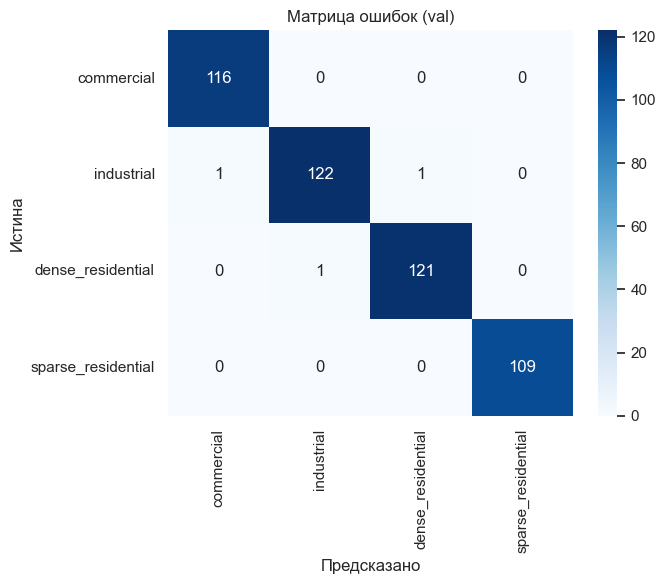

In [11]:
cm = confusion_matrix(val_labels, val_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истина')
ax.set_title('Матрица ошибок (val)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / CFG.confusion_matrix_plot, dpi=PLOT_DPI)
plt.show()

## Примеры

По 2 верных на класс + все ошибки на val.

Правильных примеров: 8 (до 2 на класс)


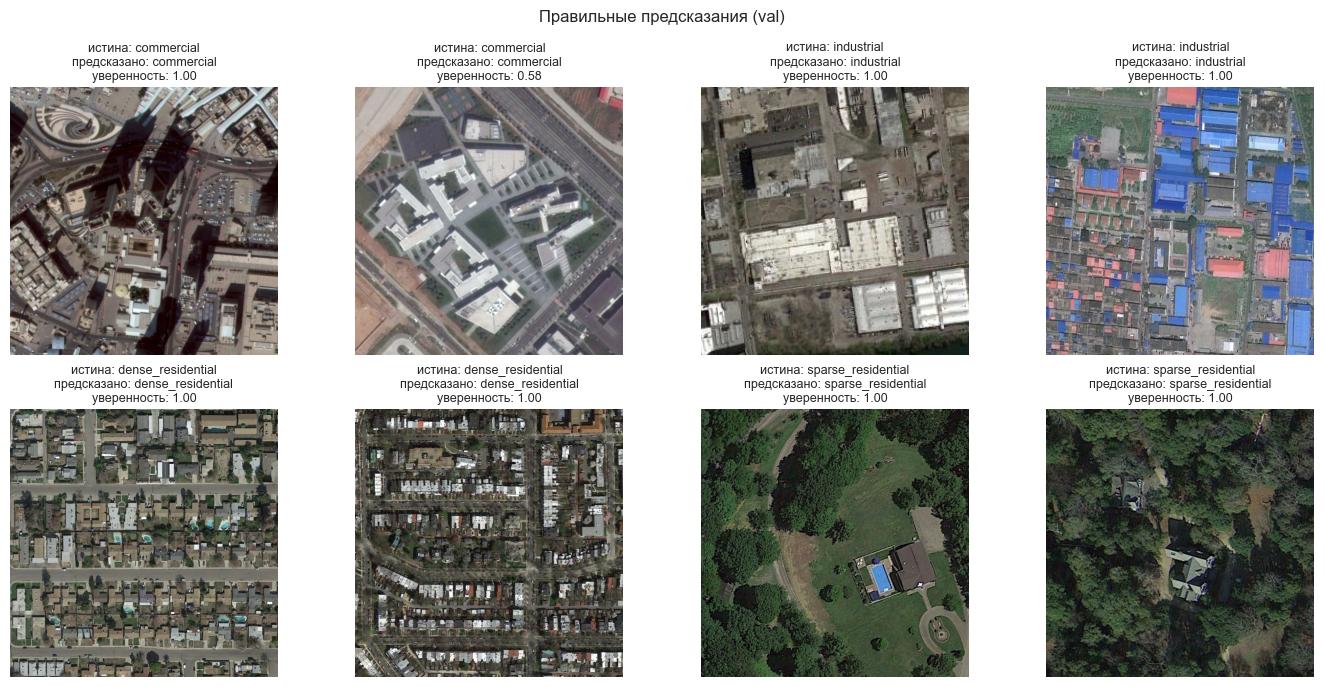

Ошибочных примеров: 3


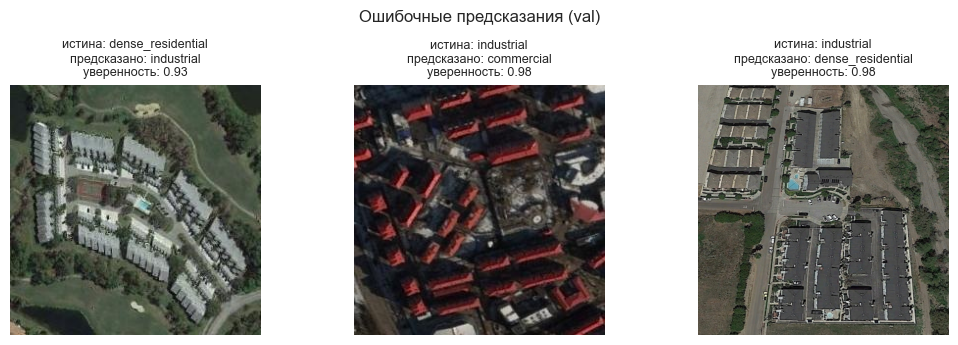

In [12]:
from PIL import Image

val_df = split_df[split_df['split'] == 'val'].reset_index(drop=True)


def show_prediction_examples(paths_df, labels, preds, probs, n_correct_per_class=CFG.n_correct_per_class, seed=RANDOM_SEED):
    """Визуализация верных и ошибочных примеров."""
    rng = np.random.default_rng(seed)

    correct_indices = []
    for cls_idx, cls_name in enumerate(CLASSES):
        cls_correct = np.where((labels == cls_idx) & (preds == cls_idx))[0]
        if len(cls_correct) == 0:
            continue
        n_pick = min(n_correct_per_class, len(cls_correct))
        pick = rng.choice(cls_correct, size=n_pick, replace=False)
        correct_indices.extend(pick.tolist())

    error_indices = np.where(preds != labels)[0].tolist()

    def _plot_grid(indices, title, filename, cols=4):
        if not indices:
            print(f'{title}: нет примеров')
            return
        cols = min(cols, len(indices))
        rows = int(np.ceil(len(indices) / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows))
        axes = np.atleast_1d(axes).ravel()
        for ax in axes[len(indices):]:
            ax.axis('off')
        for i, idx in enumerate(indices):
            img = Image.open(paths_df.iloc[idx]['path']).convert('RGB')
            true_cls = CLASSES[labels[idx]]
            pred_cls = CLASSES[preds[idx]]
            conf = float(probs[idx][preds[idx]])
            axes[i].imshow(img)
            caption = 'истина: ' + true_cls + '\nпредсказано: ' + pred_cls + f'\nуверенность: {conf:.2f}'
            axes[i].set_title(caption, fontsize=9)
            axes[i].axis('off')
        fig.suptitle(title, fontsize=12)
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / filename, dpi=PLOT_DPI, bbox_inches='tight')
        plt.show()

    print(f'Правильных примеров: {len(correct_indices)} (до {n_correct_per_class} на класс)')
    _plot_grid(
        correct_indices,
        'Правильные предсказания (val)',
        CFG.correct_examples_plot,
    )

    print(f'Ошибочных примеров: {len(error_indices)}')
    _plot_grid(
        error_indices,
        'Ошибочные предсказания (val)',
        CFG.error_examples_plot,
        cols=4,
    )


show_prediction_examples(val_df, val_labels, val_preds, val_probs)


## Выводы

1. **Качество:** macro F1 = 0.9938, точность = 0.9936 (471 img, 3 ошибки).

2. **Этап 1:** лучший LR — 1e-3 (macro F1 = 0.9728).

3. **Этап 2:** 69 эпох, лучший результат на подэтапе 1 (macro F1 = 0.9938). Дальнейшая разморозка не помогла.

4. **Классы:** `dense`/`sparse_residential` — F1 = 1.0; чаще путают `commercial` и `industrial`.

In [ ]:
report_dict = classification_report(
    val_labels, val_preds, target_names=CLASSES, output_dict=True, zero_division=0
)
worst_class = min(CLASSES, key=lambda c: report_dict[c]['f1-score'])
best_class = max(CLASSES, key=lambda c: report_dict[c]['f1-score'])

history = stage2_result['history']
best_epoch_idx = int(np.argmax(history['val_f1']))
best_global_epoch = best_epoch_idx + 1
train_acc_at_best = history['train_acc'][best_epoch_idx]
val_acc_at_best = history['val_acc'][best_epoch_idx]
acc_gap = train_acc_at_best - val_acc_at_best
n_errors = int(np.sum(val_preds != val_labels))

print('=' * 60)
print('ИТОГИ — ConvNeXt-Tiny')
print('=' * 60)
print(f'Разбиение: обучение={len(train_ds)} валидация={len(val_ds)} тест={len(test_ds)} (70/15/15)')
print()
print('Этап 1 — подбор LR:')
for lr, res in lr_search_results.items():
    marker = ' <- лучший' if lr == best_lr else ''
    print(f'  LR={lr:.0e}: macro F1={res["best_val_f1"]:.4f}, эпох={res["epochs_run"]}{marker}')
print()
print('Этап 2 — дообучение:')
for sub in stage2_result['substage_results']:
    marker = ' <- лучший' if sub['substage'] == stage2_result['best_substage'] else ''
    print(
        f'  Подэтап {sub["substage"]}: {sub["epochs_run"]} эпох, '
        f'лучший macro F1={sub["best_f1"]:.4f} (эпоха {sub["best_epoch"]}){marker}'
    )
print(f'  Всего эпох: {stage2_result["epochs_run"]}/{MAX_EPOCHS}')
print()
print('Финальная модель:')
print(f'  Лучшая эпоха: {best_global_epoch} (подэтап {stage2_result["best_substage"]})')
print(f'  macro F1={convnext_val_macro_f1:.4f}, точность={convnext_val_accuracy:.4f}, ошибок={n_errors}')
print(f'  точность обучения={train_acc_at_best:.4f}, точность валидации={val_acc_at_best:.4f}, разрыв={acc_gap:.4f}')
print()
print('Классы:')
print(f'  лучший  — {best_class}: F1={report_dict[best_class]["f1-score"]:.4f}')
print(f'  слабый  — {worst_class}: F1={report_dict[worst_class]["f1-score"]:.4f}, '
      f'прециз.={report_dict[worst_class]["precision"]:.4f}, полнота={report_dict[worst_class]["recall"]:.4f}')
print()
print(f'Модель сохранена: {best_model_path}')

ИТОГИ — ConvNeXt-Tiny
Разбиение: обучение=2197 валидация=471 тест=471 (70/15/15)

Этап 1 — подбор LR:
  LR=1e-03: macro F1=0.9834, эпох=15 <- лучший
  LR=1e-04: macro F1=0.9541, эпох=15
  LR=1e-05: macro F1=0.8030, эпох=15

Этап 2 — дообучение:
  Подэтап 1: 32 эпох, лучший macro F1=0.9938 (эпоха 4) <- лучший
  Подэтап 2: 31 эпох, лучший macro F1=0.9938 (эпоха 2)
  Подэтап 3: 8 эпох, лучший macro F1=0.9938 (эпоха 1)
  Всего эпох: 71/100

Финальная модель:
  Лучшая эпоха: 4 (подэтап 1)
  macro F1=0.9938, точность=0.9936, ошибок=3
  точность обучения=1.0000, точность валидации=0.9936, разрыв=0.0064

Классы:
  лучший  — sparse_residential: F1=1.0000
  слабый  — industrial: F1=0.9879, прециз.=0.9919, полнота=0.9839

Модель сохранена: D:\building-type-classification\models\convnext_best.pth


: 